# Sprint 11
Exercici 1: Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

1. Executa la connexió Python - MySQL Workbench.

2. Per a cada ítem, crea una visualització adecuada segons les variables especificades. Interpreta els resultats segons les teves dades. 

Recorda: quan seleccionis les columnes, pensa sempre en el mètode que faràs servir i inclou les que calguin per a la funció de visualització que vulguis utilitzar.

* Una variable numèrica.
* Dues variables numèriques.
* Una variable categòrica. 
* Una variable categòrica i una numèrica.
* Dues variables categòriques. 
* Tres variables combinades.
* Crea un Pairplot.

Primer importarem totes les llibreries necessaries per treballar amb grafics i per importar les dades de MySQL Workbench (el cual ja està connectat al VSC). També li donarem un format general als gràfics, i mostrarem les taules i les seves columnes. 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from getpass import getpass

#Configurem visual per defecte
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8,5)

#Connexió
user = "root"
password = getpass("Contrasenya MySQL: ")
host = "127.0.0.1"
port = 3307
database = "sprint4"

engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}")

#Prova: hauria de retornar les 7 taules del Sprint4
pd.read_sql('SHOW TABLES;', engine)

#Explorar estructura de todas las tablas
tablas = ['card_status', 'companies', 'credit_cards', 'data_users', 'products', 'transactions', 'transactions_products']

for tabla in tablas:
    print(f"\n{'='*40}")
    print(f"TABLA: {tabla}")
    print('='*40)
    df_temp = pd.read_sql(f"SELECT * FROM {tabla} LIMIT 3;", engine)
    print(df_temp.dtypes)
    print(df_temp.head(3))


TABLA: card_status
card_id    object
status     object
dtype: object
    card_id  status
0  CcS-4857  activa
1  CcS-4858  activa
2  CcS-4859  activa

TABLA: companies
id              object
company_name    object
phone           object
email           object
country         object
website         object
dtype: object
       id               company_name           phone  \
0  b-2222  Ac Fermentum Incorporated  06 85 56 52 33   
1  b-2226   Magna A Neque Industries  04 14 44 64 62   
2  b-2230                Fusce Corp.  08 14 97 58 85   

                              email        country  \
0  donec.porttitor.tellus@yahoo.net        Germany   
1       risus.donec.nibh@icloud.org      Australia   
2              risus@protonmail.edu  United States   

                            website  
0      https://instagram.com/site\r  
1    https://whatsapp.com/group/9\r  
2  https://pinterest.com/sub/cars\r  

TABLA: credit_cards
id               object
user_id          object
iban             

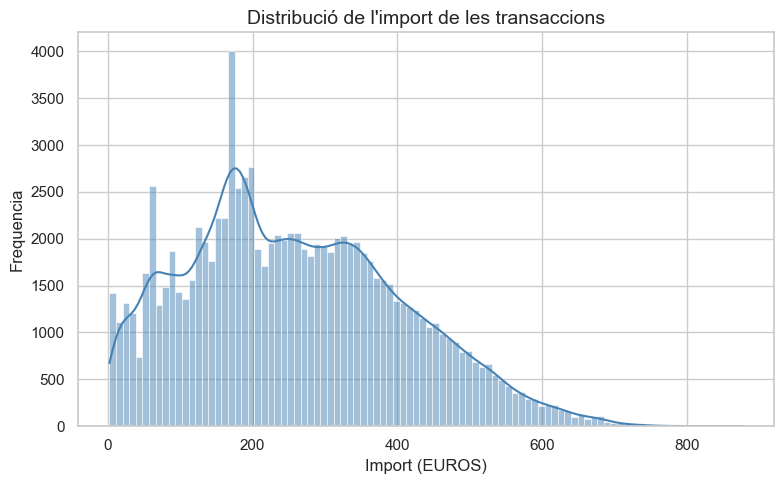

In [16]:
#Ex1.1 - Una variable numèrica
df_amount = pd.read_sql("SELECT amount FROM transactions;", engine) 
#Aquí estem important només la columna amount desde el MySQL a través del engine!

fig, ax = plt.subplots() #Aquí estem creant el plot.
sns.histplot(df_amount['amount'], kde = True, color= 'steelblue', ax = ax)
#Aquí li estem enlassant al plot, un histograma que a la vegada s'enllassa amb la variable amount importada préviament.

#Aquí definim el xlabel, ylabel i el títol. 
ax.set_title("Distribució de l'import de les transaccions", fontsize=14)
ax.set_xlabel('Import (EUROS)')
ax.set_ylabel('Frequencia')
plt.tight_layout(); 

Títol del Gràfic: Distribució de l'import de les transaccions. 
Variable: amount.transactions. 
Tipus de variable: 1 (numèrica). 
Tipus de gràfic: histograma + KDE. 

Què veiem? 
* La majoria de les transaccions se situen entre 1 i 400 euros, amb el pic màxim al voltant dels 175-200 euros. 
* La distribució és asimètrica cap a la dreta (right-skewed) - la cua s'estira cap als valors alts però hi ha molt poques transaccions per sobre dels 600 euros.
* Hi ha un petit repunt al voltant dels 50-75 euros que podria significar un segon grup de transaccions (per exemple d'un producte concret) habituals de valor més baix. 

Què significa pel negoci? 
* L'import típic d'una transacció ronda els 175-200 euros.
* Existeixen transaccions puntuals de valor menys elevat en els 50-75 euros que també mostren un peak de freqûencia, lo que pot significar un producte o combi de productes estrella habituals. 

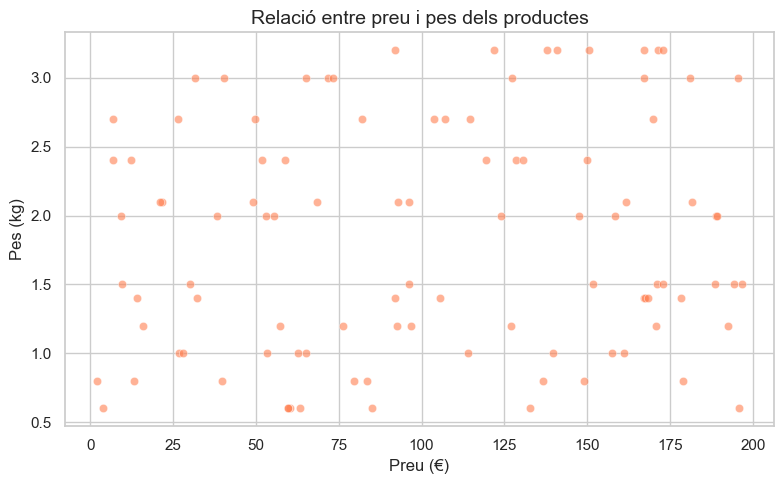

In [17]:
#Ex1.2 - Dues variables numèriques
df_prod = pd.read_sql("SELECT price, weight FROM products;", engine)

fig, ax = plt.subplots()
sns.scatterplot(data=df_prod, x="price", y="weight", alpha=0.6, color="coral", ax=ax)

ax.set_title("Relació entre preu i pes dels productes", fontsize=14)
ax.set_xlabel("Preu (€)")
ax.set_ylabel("Pes (kg)")
plt.tight_layout();

Títol del Gràfic: Relació entre preu i pes dels productes. 
Variable(s): price.products, weight.products. 
Tipus de variable(s): 2 (numèriques). 
Tipus de gràfic: scatterplot. 

Què veiem? 
* Els punts estan dispersos sense cap patró clar — no hi ha una línia ascendent ni descendent visible. 
* El pes dels productes se situa entre 0.5 i 3.2 kg i el preu entre 0 i ~200€.

Què significa pel negoci? 
* No hi ha correlació entre preu i pes — un producte car no implica que sigui pesat ni viceversa.

C:\Users\User\AppData\Local\Temp\ipykernel_8400\4152231717.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_status, x="status", palette="Set2", ax=ax)


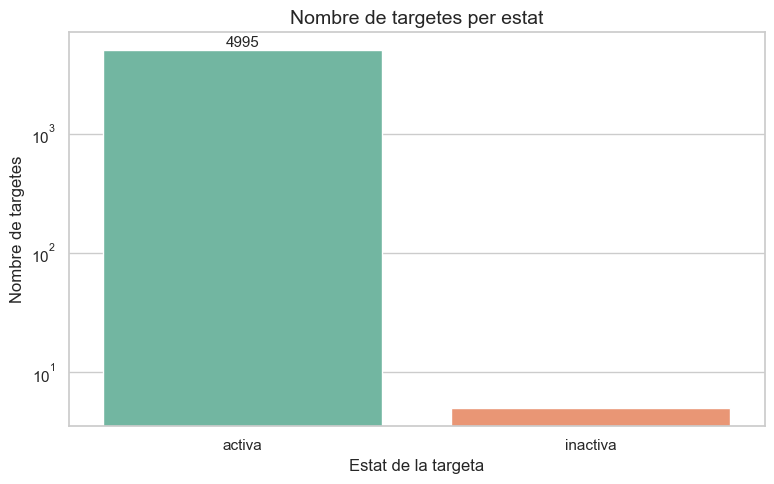

In [ ]:
#Ex1.3 - Una variable categòrica
df_status = pd.read_sql("SELECT status FROM card_status;", engine)

fig, ax = plt.subplots()
sns.countplot(data=df_status, x="status", palette="Set2", ax=ax)

ax.set_title("Nombre de targetes per estat", fontsize=14)
ax.set_xlabel("Estat de la targeta")
ax.set_ylabel("Nombre de targetes")
ax.bar_label(ax.containers[0], fontsize=11)
plt.tight_layout()
ax.set_yscale("log");

Títol del Gràfic: Nombre de targetes per estat. 
Variable(s): status.card_status. 
Tipus de variable(s): 1 (categòrica). 
Tipus de gràfic: countplot. 

PS: Hem mogut el grafic a una escala logaritmica per poder observar les targetes inactives (5).

Què veiem? 
* Hi ha dues categories: activa i inactiva. 
* La immensa majoria de les targetes estàn actives.


Què significa pel negoci? 
* La base de clients és molt activa, cosa positiva per al negoci.
* També podria indicar o bé que les targetes inactives s'eliminen del sistema o bé que existeix algún error de càlcul. 

C:\Users\User\AppData\Local\Temp\ipykernel_8400\2117762959.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_trans, x="estat", y="amount", palette="Set1", ax=ax)


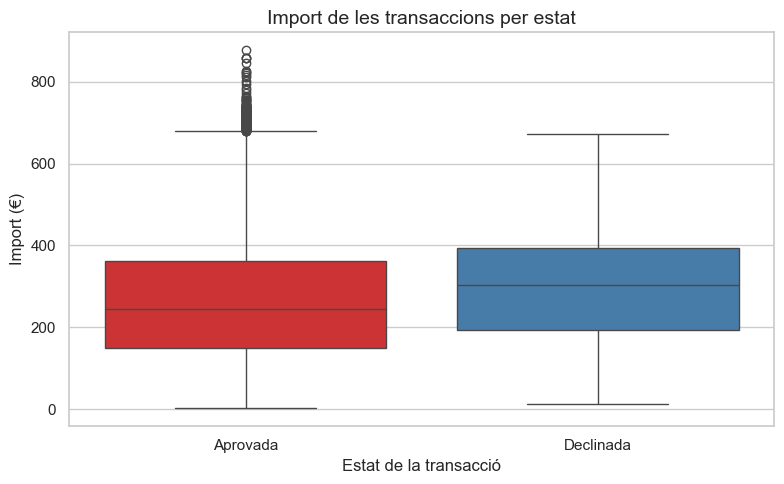

In [19]:
#Ex1.4 - Variable categòrica + numèrica
df_trans = pd.read_sql("SELECT amount, declined FROM transactions;", engine)
df_trans["estat"] = df_trans["declined"].map({0: "Aprovada", 1: "Declinada"})
#Aquí simplement estem subtituint la columna declined per una variable categòrica.

fig, ax = plt.subplots()
sns.boxplot(data=df_trans, x="estat", y="amount", palette="Set1", ax=ax)

ax.set_title("Import de les transaccions per estat", fontsize=14)
ax.set_xlabel("Estat de la transacció")
ax.set_ylabel("Import (€)")
plt.tight_layout();

Títol del Gràfic: Import de les transaccions per estat. 
Variable(s): declined.transactions, amount.transactions. 
Tipus de variable(s): 2 (categòrica i numèrica). 
Tipus de gràfic: boxplot. 

Què veiem? 
* Hi ha dues categories: aprovades i declninades. 
* La línia del mig del box és la mediana - uns 240 euros les aprovades, uns 300 euros les declinades.
* La caixa representa el 50% central de les dades (del quartil 25% al 75%).
* Les línies que s'extenen fora la caixa son els valors mín i màx sense comptar outliers.
* Els cercles fora la caixa son els valors outliers. 
* Existeixen valors atípics en les transactions aprovades de entre 650 a 800 euros.
* Les transaccions declinades tenen imports més alts en general.


Què significa pel negoci? 
* Les transaccions declinades tenen imports més alts en general. Aprofundir més.

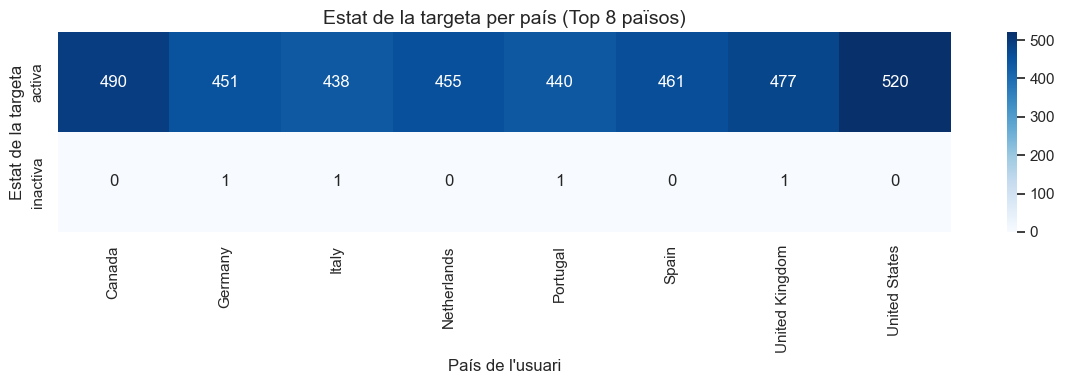

In [ ]:
#Ex1.5 - Dues variables categòriques
df_card_user = pd.read_sql("""
    SELECT cs.status, du.country
    FROM card_status cs
    JOIN credit_cards cc ON cs.card_id = cc.id
    JOIN data_users du ON cc.user_id = du.id;
""", engine)

# Filtrem els 8 països amb més registres per llegibilitat
top_countries = df_card_user["country"].value_counts().head(8).index
df_filtered = df_card_user[df_card_user["country"].isin(top_countries)]

crosstab = pd.crosstab(df_filtered["status"], df_filtered["country"])

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues", ax=ax)

ax.set_title("Estat de la targeta per país (Top 8 països)", fontsize=14)
ax.set_xlabel("País de l'usuari")
ax.set_ylabel("Estat de la targeta")
plt.tight_layout();

Títol del Gràfic: Estat de la targeta per país (Top 8 països). 
Variable(s): cs.status, du.country. 
Tipus de variable(s): 2 (categòriques). 
Tipus de gràfic: heatmap -  sobre crosstab. 

Què veiem? 
* Hi ha dues variables categòriques: cs.status (activa / inactiva) i du.country (paísos dintre de data_users). 
* En pro a la llegibilitat només hem seleccionat els 8 paísos amb més targetes actives. 
* Veiem que totes tenen un número de targetes actives bastant regular entre 438 i 520.
* 4 de les 5 targetes inactives es concentren en aquesys 8 paísos.
* La suma total de les targetes actives en el top8 de paisos es de 3732 actives.
* El país amb més targetes actives es United States.


Què significa pel negoci? 
* Gairebé el 75% de les targetes usades en el marketplace pertanyen als paísos del top8. 
* No podem inferir amb aquesta informació si el 75% de les transaccios pertanyen al top8 ja que no tenim cap mètrica sobre transactions / credit_card. 

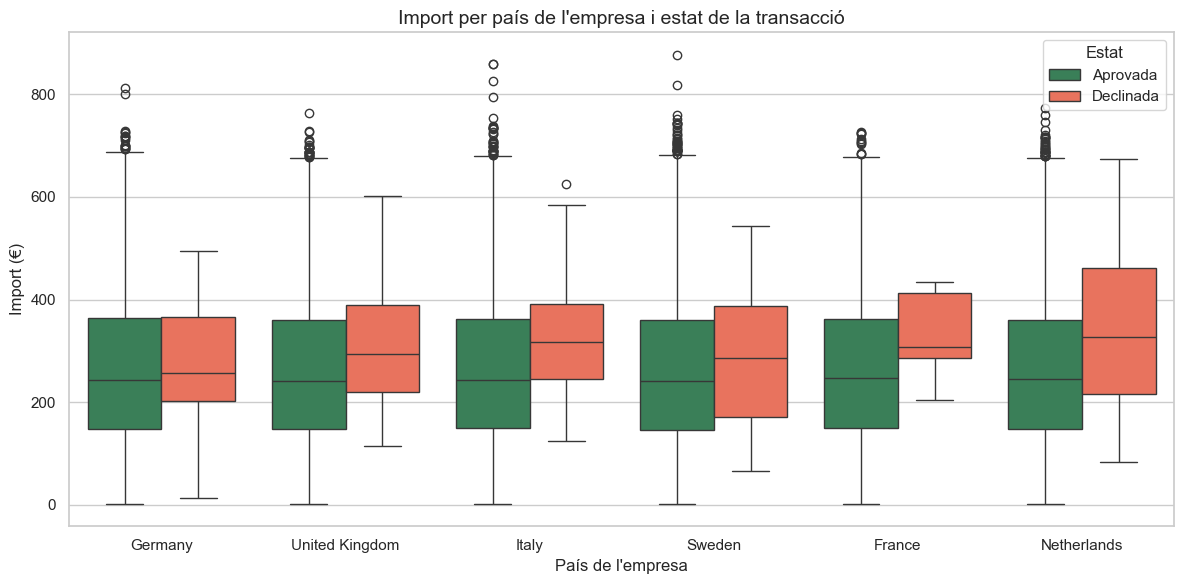

In [ ]:
#Ex1.6 - Tres variables combinades
df_trans_company = pd.read_sql("""
    SELECT t.amount, t.declined, c.country
    FROM transactions t
    JOIN companies c ON t.company_id = c.id;
""", engine)

df_trans_company["estat"] = df_trans_company["declined"].map({0: "Aprovada", 1: "Declinada"})

top_6 = df_trans_company["country"].value_counts().head(6).index
df_filtered = df_trans_company[df_trans_company["country"].isin(top_6)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_filtered, x="country", y="amount", hue="estat",
            palette={"Aprovada": "seagreen", "Declinada": "tomato"}, ax=ax)

ax.set_title("Import per país de l'empresa i estat de la transacció", fontsize=14)
ax.set_xlabel("País de l'empresa")
ax.set_ylabel("Import (€)")
ax.legend(title="Estat")
plt.tight_layout();

Títol del Gràfic: Import per país de l'empresa i estat de la transacció. 
Variable(s): amount.transactions, declined.transactions, country.companies. 
Tipus de variable(s): 3 (2 categòriques i 1 numèrica). 
Tipus de gràfic: diferents boxplots. 

Què veiem? 
* Hi ha dues variables categòriques: declined.transactions i country.companies. I una numèrica: import. 
* El gràfic mostra bàsicament el top6 de paísos amb empreses que tenen més transaccions en el marketplace, diferenciant-les entre aprovades i declined.
* Veiem que tots el paísos tenen una mediana de transactions declined superior a les aprovades.
* El patró de l'exercici 1.4 es repeteix consistentment quan segreguem les dades per paísos.


Què significa pel negoci? 
* El fet que les transaccions declinades tinguin imports més alts a tots els països suggereix que hi ha un llindar d'import a partir del qual el sistema declina les transaccions — probablement per mesures anti-frau.
* Netherlands destaca perquè la caixa vermella (declinades) és notablement més alta que la resta de països — podria ser interessant investigar-ho.

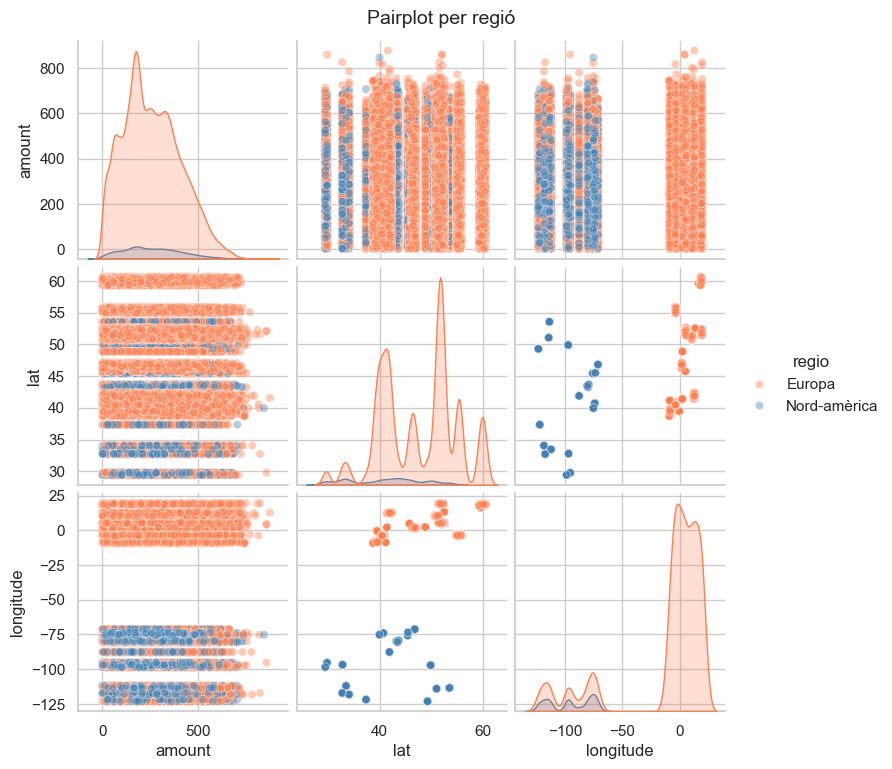

In [6]:
# Ex1.7 - Pairplot amb hue per regió
df_pairplot = pd.read_sql("""
    SELECT t.amount, t.lat, t.longitude, c.country
    FROM transactions t
    JOIN companies c ON t.company_id = c.id;
""", engine)

nord_america = ["United States", "Canada", "Mexico"]
df_pairplot["regio"] = df_pairplot["country"].apply(
    lambda x: "Nord-amèrica" if x in nord_america else "Europa"
)

sns.pairplot(df_pairplot[["amount", "lat", "longitude", "regio"]],
             hue="regio",
             palette={"Nord-amèrica": "steelblue", "Europa": "coral"},
             diag_kind="kde",
             plot_kws={"alpha": 0.4})

plt.suptitle("Pairplot per regió", y=1.02, fontsize=14)
plt.show()


Títol del Gràfic: Pairplot de variables numèriques de transaccions amb hue a Nord Amèrica. 
Variable(s): amount.transactions, longitud, latitude. 
Tipus de variable(s): 3 (3 numèriques) + 1 categòrica. 
Tipus de gràfic: Pairplot. 

Què veiem? 
* La distribució de amount és pràcticament idèntica entre Europa i Nord-amèrica — les dues corbes KDE se solapen quasi completament. 
* A lat i longitude la separació és clara i esperada: els punts blaus (Nord-amèrica) se situen a latituds 25-50 i longituds -75 a -125, mentre que els taronges (Europa) se situen a latituds 35-60 i longituds properes a 0.
* Al gràfic lat vs longitude es veuen clarament dos núvols separats — un per cada continent.

Què significa pel negoci? 
* El negoci té una distribució geogràfica clara en dos blocs, però ambdós mercats es comporten de manera homogènia. Això és positiu perquè indica que no cal una estratègia de preus diferenciada per regió.